# Compare hit rate/ average activity by plate a subgroup in plate

In [1]:
# builtins and utils
import os
import json
import hashlib
from tqdm.notebook import tqdm
import itertools

# DS stack
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('white')
sns.set_context('talk')
import scipy.stats as stats

# Downstream supervised tools
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso, LinearRegression, ElasticNet
from sklearn.feature_selection import SelectFromModel, VarianceThreshold 
import joblib

# aide predict
import aide_predict as ap
from aide_predict.utils.plotting import plot_mutation_heatmap, plot_protein_sequence_heatmap

# data handling
import datasets

# typing
from typing import List, Dict, Tuple, Union

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
from sklearn.exceptions import ConvergenceWarning

In [3]:
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [4]:
# globals
POSITION_OFFSET = 10
MAX_MUTATION_COUNT = 4

MUTATION_COUNTS_OBSERVED = {}

In [5]:
def get_importance_from_ttr(ttr):
    return ttr.regressor_.coef_

In [6]:
def add_observed_mutations(mutations: List[str]):
    for mutation in mutations:
        if mutation in MUTATION_COUNTS_OBSERVED:
            MUTATION_COUNTS_OBSERVED[mutation] += 1
        else:
            MUTATION_COUNTS_OBSERVED[mutation] = 1

In [7]:
# mutating wt to new variant
# the aide package does nto have an option for position offset
def mutate_wt(
        wild_type: ap.ProteinSequence,
        mutations: Union[str, List[str]],
        offset: int = POSITION_OFFSET,
        one_indexed: bool=True,
        return_str: bool=True
    ) -> ap.ProteinSequence:
    """"""
    if isinstance(mutations, str):
        mutations = [mutations]

    mutated = list(str(wild_type))
    for mutation in mutations:
        original_aa = mutation[0]
        position = int(mutation[1:-1])
        new_aa = mutation[-1]
        if one_indexed:
            position = position - 1
        if offset != 0:
            position = position - offset
        assert wild_type[position] == original_aa, f"Mutation {mutation} does not match wild type {wild_type[position]}"
        mutated[position] = new_aa
    if return_str:
        return "".join(mutated)
    else:
        return ap.ProteinSequence("".join(mutated))


In [8]:
def get_mutations(
    wt: ap.ProteinSequence,
    variant: ap.ProteinSequence,
    offset: int = POSITION_OFFSET,
    one_indexed: bool=True
) -> List[str]:
    """Parse mutations from two protein sequences"""
    if not isinstance(wt, ap.ProteinSequence):
        wt = ap.ProteinSequence(wt)
    if not isinstance(variant, ap.ProteinSequence):
        variant = ap.ProteinSequence(variant)
    mutations = wt.get_mutations(variant)
    mutations_ = []
    for mutation in mutations:
        position = int(mutation[1:-1])
        if not one_indexed:
            position = position - 1
        if offset != 0:
            position = position + offset
        mutations_.append(f"{mutation[0]}{position}{mutation[-1]}")
    return mutations_

In [9]:
# hashing protein sequences
def protein_hash(protein: str) -> str:
    return hashlib.md5(str(protein).encode()).hexdigest()

In [10]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [11]:
def get_foldlike_iterator_from_df(df, split_mask_prefix):
    fold_index_iterator = []
    for col in df.columns:
        if col.startswith(split_mask_prefix):
            # the column is a bolean - 0 for train, 1 for test
            # we need to get indexes for train and test
            fold_index_iterator.append((
                df[df[col] == 0].index.tolist(),
                df[df[col] == 1].index.tolist()
            ))
    return fold_index_iterator


In [12]:
class WeightedMAEScorer:
    def __init__(self, n_bins=20):
        self.n_bins = n_bins
        self.bin_edges = None
        self.bin_weights_map = None
    
    def fit(self, y):
        """Compute bin edges and weights from training data"""
        y = np.array(y)
        bin_counts, self.bin_edges = np.histogram(y, bins=self.n_bins)
        
        # fill in 0s with 1 to avoid division by 0
        bin_counts = np.maximum(bin_counts, 1)
        
        # Store the weight for each bin
        self.bin_weights_map = 1 / bin_counts
        
        return self
    
    def get_weights(self, y):
        """Get weights for new data using pre-computed bins"""
        if self.bin_edges is None:
            raise ValueError("Scorer must be fitted before getting weights")
            
        y = np.array(y)
        bin_index = np.clip(np.digitize(y, self.bin_edges) - 1, 0, self.n_bins - 1)
        
        # Use pre-computed weights
        weights = self.bin_weights_map[bin_index]
        
        # Normalize weights
        weights = weights / np.sum(weights)
        
        return weights
    
    def score(self, y_true, y_pred):
        """Calculate weighted negative MAE using pre-computed bins"""
        y_true, y_pred = np.array(y_true), np.array(y_pred)
        weights = self.get_weights(y_true)
        return -np.average(np.abs(y_true - y_pred), weights=weights)

In [13]:
def random_hyperopt(model_pipeline, param_distributions, X, y, n_iter=100, cv=10, n_jobs=1, scorer='neg_mean_absolute_error', **kwargs):
    search = RandomizedSearchCV(
        model_pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        cv=cv,
        n_jobs=n_jobs,
        verbose=10,
        random_state=42,
        scoring=scorer,
        error_score="raise",
    )
    search.fit(X, y, **kwargs)

    results_df = pd.DataFrame(search.cv_results_)
    best_params = search.best_params_
    best_score_mean = results_df[results_df['rank_test_score'] == 1]['mean_test_score'].values[0]
    best_score_std = results_df[results_df['rank_test_score'] == 1]['std_test_score'].values[0]
    return results_df, best_params, best_score_mean, best_score_std

## 1.1 Data loading

In [14]:
alignment = ap.ProteinSequences.from_fasta('../data/msa/mda_hacl.a2m')
wt = alignment[0]

In [15]:
len(alignment[0].with_no_gaps())

565

In [16]:
ssm_data_raw = pd.read_excel('../data/experimental/round0_1_compiled.xlsx', sheet_name='Round 1 Data', skiprows=1)

In [17]:
# remove column 0, 2 and row 1
ssm_data = ssm_data_raw.drop(ssm_data_raw.columns[0], axis=1)
ssm_data = ssm_data.drop(ssm_data.columns[1], axis=1)
ssm_data = ssm_data.drop(ssm_data.index[0])
# format long with columns [mutation_string, original, position, mutation, activity]
ssm_data.rename(columns={'Unnamed: 1': 'original_position_string'}, inplace=True)

In [18]:
# parse positions/mutations
ssm_data['original_aa'] = ssm_data['original_position_string'].str[0]
ssm_data['position'] = ssm_data['original_position_string'].str[1:].astype(int)
ssm_data.drop(columns=['original_position_string'], inplace=True)
ssm_data = ssm_data.melt(id_vars=['original_aa', 'position'], var_name='mutation', value_name='activity').sort_values(by='position').reset_index(drop=True)

In [19]:
# compute the position on our sequence, 0 indexed
ssm_data['position_on_wt_0_indexed'] = ssm_data['position'] - POSITION_OFFSET - 1
for _, row in ssm_data.iterrows():
    assert wt[row['position_on_wt_0_indexed']] == row['original_aa']

In [20]:
ssm_data = ssm_data.dropna()

# add full sequence
ssm_data['mutation_string'] = ssm_data['original_aa'] + ssm_data['position'].astype(str) + ssm_data['mutation']
ssm_data['variant'] = ssm_data['mutation_string'].apply(lambda x: mutate_wt(wt, x))

In [21]:
ssm_data['hash'] = ssm_data['variant'].apply(protein_hash)

In [22]:
ssm_data['id'] = 'ssm_' + ssm_data['mutation_string']

In [23]:
round1_data = pd.read_excel('../data/experimental/round0_1_compiled.xlsx', sheet_name='Round 2 data')

In [24]:
round1_data.rename(columns={'FC relative to WT': 'activity', 'Mutations': 'id'}, inplace=True)
round1_data

,id,activity
0,Additive_G556R|T561K,0.141086
1,Additive_T561S|D403N,0.196669
2,Additive_S569R|D403N,0.268741
3,Additive_G556R|D403N,0.272829
4,Additive_G556R|S569R,0.313584
...,...,...
283,UCB_V83W|A420R|S569F,0.000000
284,UCB_V83W|T561C|D403L,0.000000
285,UCB_A399T|V83L|A420N,0.017555
286,UCB_V83T|G556M|S569C,0.079666


In [25]:
# convert mutations into variants
def get_variant_from_id(id: str) -> str:
    mutations = id.split('_')[-1]
    mutations = mutations.split('|')
    return mutate_wt(wt, mutations)

round1_data['variant'] = round1_data['id'].apply(get_variant_from_id)

In [26]:
round1_data['hash'] = round1_data['variant'].apply(protein_hash)

In [27]:
# now load round 2
round2_raw = pd.read_excel('../data/experimental/round2_compiled.xlsx', sheet_name=0, index_col=0)
round2_data = round2_raw.copy()

In [28]:
round2_data['id'] = round2_data['Mutant'].apply(lambda x: 'round2_' + x)
round2_data['mutations'] = round2_data['Mutant'].apply(lambda x: x.split(';'))
round2_data['variant'] = round2_data['mutations'].apply(lambda x: mutate_wt(wt, x))
round2_data['hash'] = round2_data['variant'].apply(protein_hash)
round2_data.rename(columns={'Activity': 'activity'}, inplace=True)


In [29]:
round2_data

,Mutant,activity,id,mutations,variant,hash
NaN,A399G;S407A;S569Q,0.388532,round2_A399G;S407A;S569Q,"[A399G, S407A, S569Q]",MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,2ca632b5c2b7579694a59af3a35e8e28
NaN,A399G;S407A;A570Q,3.627074,round2_A399G;S407A;A570Q,"[A399G, S407A, A570Q]",MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,4a00caa0c898b04ba723690553574999
NaN,A399G;G556P;A570Q,5.934105,round2_A399G;G556P;A570Q,"[A399G, G556P, A570Q]",MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,3a3e7205a87ecd565eb8fd76d43a2b00
NaN,A399G;S407A;G556P,5.388647,round2_A399G;S407A;G556P,"[A399G, S407A, G556P]",MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,2e42592692335522d9ad67a9d37f722c
NaN,A399G;S407A;T561G,1.532994,round2_A399G;S407A;T561G,"[A399G, S407A, T561G]",MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,9e9d7e1fa944811f580323d38065aeaa
...,...,...,...,...,...,...
NaN,V83G;S407Q;S425T;S569G;A570G,2.255788,round2_V83G;S407Q;S425T;S569G;A570G,"[V83G, S407Q, S425T, S569G, A570G]",MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,1feb7fd6997ef1fe33fb55bfc8c31f52
NaN,V83G;A420T;G556Q;S569D;A570S,3.068818,round2_V83G;A420T;G556Q;S569D;A570S,"[V83G, A420T, G556Q, S569D, A570S]",MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,8ffd536d96fdd9e09757af9e94d7d439
NaN,V83G;G556A;T561I;S569G;A570D,2.196333,round2_V83G;G556A;T561I;S569G;A570D,"[V83G, G556A, T561I, S569G, A570D]",MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,636a71778cb460d4fdf5b6e22ddd3921
NaN,V83G;S407Q;G556I;T561M;A570Q,2.096388,round2_V83G;S407Q;G556I;T561M;A570Q,"[V83G, S407Q, G556I, T561M, A570Q]",MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,b4ec96f43fb94ce21d36498332afac1f


In [30]:
# combine datasets
combined_data = pd.concat([ssm_data[['id', 'activity', 'variant', 'hash']], round1_data], axis=0)[['id', 'hash', 'variant', 'activity']].reset_index(drop=True)
combined_data = pd.concat([combined_data, round2_data[['id', 'hash', 'variant', 'activity']]], axis=0)[['id', 'hash', 'variant', 'activity']].reset_index(drop=True)

In [31]:
# locate duplicate sequences
for _, group in combined_data.groupby('hash'):
    if len(group) > 1:
        print(group)
        

                        id                              hash  \
1464  UCB_A399T|V83L|A420N  32ef18c5014cf2d20d8f37268201fbf4   
1557  UCB_A399T|V83L|A420N  32ef18c5014cf2d20d8f37268201fbf4   

                                                variant  activity  
1464  MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...  0.000000  
1557  MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...  0.017555  
             id                              hash  \
1      ssm_V35V  354634911f28df897d00b02eb6fbf492   
25     ssm_V36V  354634911f28df897d00b02eb6fbf492   
50     ssm_G37G  354634911f28df897d00b02eb6fbf492   
70     ssm_I38I  354634911f28df897d00b02eb6fbf492   
88     ssm_P39P  354634911f28df897d00b02eb6fbf492   
...         ...                               ...   
1162  ssm_A568A  354634911f28df897d00b02eb6fbf492   
1175  ssm_S569S  354634911f28df897d00b02eb6fbf492   
1198  ssm_A570A  354634911f28df897d00b02eb6fbf492   
1236  ssm_P572P  354634911f28df897d00b02eb6fbf492   
1265  ssm_K573K  354

Looks like wild type and just 1 data point in the ucb data that was duplicate

In [32]:
plate3 = pd.read_csv('../data/round1/designed_plates/plate3_ucb.csv')

In [33]:
len(plate3['hash'].value_counts())

96

In [34]:
plate3['hash'] = plate3['variant'].apply(protein_hash)

In [35]:
plate3[~(plate3['hash'].isin(combined_data['hash']))]

,hash,variant,mutations,type
79,afd3d1a1fb8d8df802376a9be99ff9d0,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,V83W|T561C|D403G,UCB


In [36]:
# aggregate over hash
combined_data = combined_data.groupby('hash').agg({
    'variant': 'first',
    'activity': 'mean',
    'id': 'first'
}).reset_index()

In [37]:
combined_data[combined_data['id'].str.startswith('round2')]

,hash,variant,activity,id
26,044e08e9703f645797853a6750f39942,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,0.909455,round2_A399G;A420T;G556D;T561G;S569D
55,085d02ade1033dcfc684c92acaf95b34,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,5.208412,round2_A399G;S407T;S569K
110,12b4f60fe3b8443f466fad33776f948e,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,1.705115,round2_V83G;S407A;G556D;T561M;S569K
118,13fd99e91e4e50d3e0c5a4e1391afc05,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,0.845057,round2_V83A;A399G;S425A
148,191c5fe084a0d4f1884098eecea8527f,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,1.856333,round2_V83G;S407A;A420T;G556P;T561N
...,...,...,...,...
1508,f1de3a5298e3cf83e3d6a747431ef83b,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,2.290486,round2_A399G;G556D;T561Q;S569A;A570E
1519,f4e4ac192b5102f6f0f091bd9ff2d7d2,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,0.000000,round2_A399G;A420M;S425T;T561G;S569Q
1530,f5f662fea01371a8283daf54bcd7f854,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,0.827986,round2_V83A;A399G;G556S
1531,f60ea72da9502ab41e43c93c779b0020,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,0.606307,round2_V83A;S425A;G556A;T561G;A570D


In [38]:
def get_dataset_source(id):
    if id.startswith('ssm'):
        return 'ssm'
    elif id.startswith('Greedy'):
        return 'order 2/3 round 1'
    elif id.startswith('UCB'):
        return 'UCB'
    elif id.startswith('Additive'):
        return 'additive'
    elif id.startswith('round2'):
        mutations = id.split('_')[-1]
        mutations = mutations.split(';')
        if len(mutations) >3:
            return 'order 5 round 2'
        else:
            return 'order 2/3 round 2'

    elif id.startswith('TA'):
        return 'TA'    
    
    else:
        raise ValueError(f"Unknown id {id}")

combined_data['source'] = combined_data['id'].apply(get_dataset_source)
    

In [39]:
combined_data['num_mutations'] = combined_data['variant'].apply(lambda x: len(get_mutations(wt, x, one_indexed=False, offset=POSITION_OFFSET)))

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='num_mutations', ylabel='Count'>

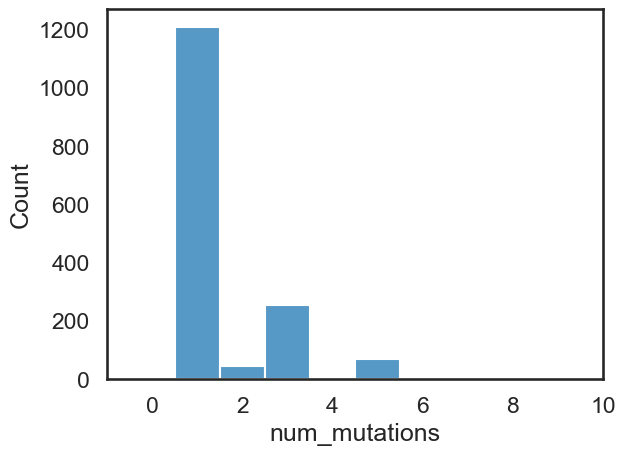

In [40]:
sns.histplot(combined_data['num_mutations'], bins=range(1, 6), discrete=True)

In [41]:
def get_method(source):
    if source == 'ssm':
        return 'ssm'
    elif source == 'additive':
        return 'additive'
    elif source in ['order 2/3 round 1', 'order 2/3 round 2', 'order 5 round 2']:
        return 'Greedy'
    elif source == 'UCB':
        return 'UCB'
    elif source == 'TA':
        return 'TA'
    else:
        raise ValueError(f"Unknown source {source}")
    
combined_data['method'] = combined_data['source'].apply(get_method)

## Plot: activity distro versus group

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9

<Axes: xlabel='activity', ylabel='Density'>

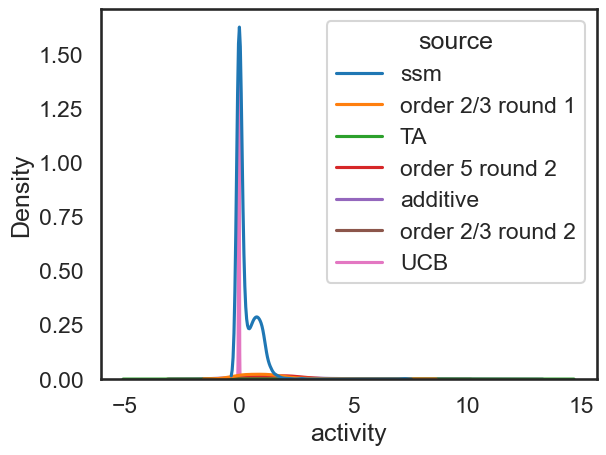

In [42]:
sns.kdeplot(
    data = combined_data,
    x='activity',
    hue='source',
    fill=False,
    common_norm=True, 
    cumulative=False,
)

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is de

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'ssm'),
  Text(1, 0, 'order 2/3 round 1'),
  Text(2, 0, 'TA'),
  Text(3, 0, 'order 5 round 2'),
  Text(4, 0, 'additive'),
  Text(5, 0, 'order 2/3 round 2'),
  Text(6, 0, 'UCB')])

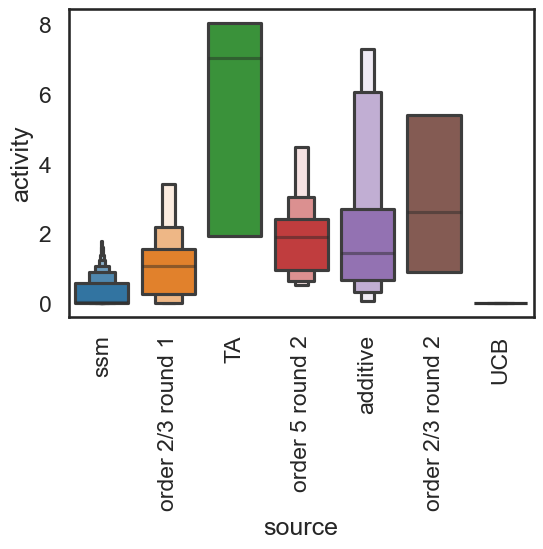

In [43]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxenplot(
    data = combined_data,
    x='source',
    y='activity',
    showfliers=False
)
# rotate x labels
plt.xticks(rotation=90)

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/categorical.py:1794: FutureWarning: use_inf_as_na option is de

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'additive'),
  Text(1, 0, 'order 2/3 round 1'),
  Text(2, 0, 'order 2/3 round 2'),
  Text(3, 0, 'order 5 round 2'),
  Text(4, 0, 'ssm')])

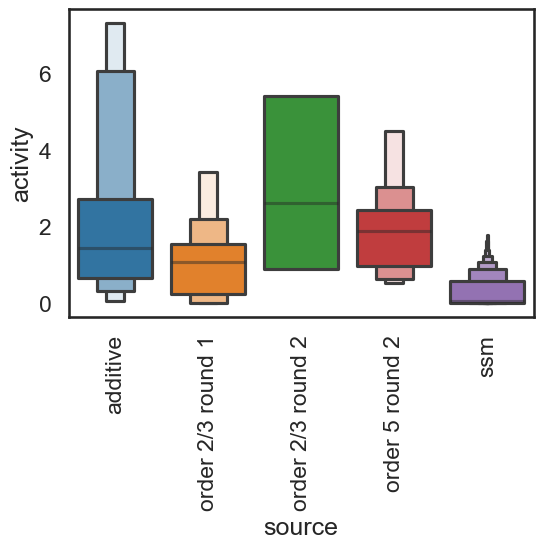

In [44]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxenplot(
    data = combined_data[~combined_data['source'].isin(['TA', 'UCB'])].sort_values(by='source'),
    x='source',
    y='activity',
    showfliers=False
)
# rotate x labels
plt.xticks(rotation=90)

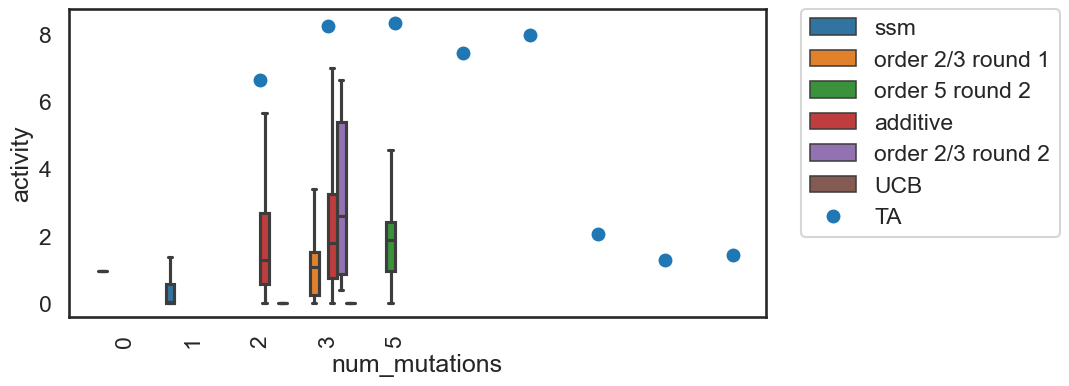

In [45]:
combined_data_minus_ta = combined_data[~combined_data['source'].isin(['TA'])]
ta_data = combined_data[combined_data['source'].isin(['TA'])]

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(
    data = combined_data_minus_ta,
    x='num_mutations',
    hue='source',
    y='activity',
    showfliers=False
)
ax.plot(ta_data['num_mutations'], ta_data['activity'], 'o', label='TA')
# rotate x labels
plt.xticks(rotation=90)
# move legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [46]:
X = ap.ProteinSequences.from_list(combined_data['variant'].tolist())

In [47]:
ohe = ap.OneHotProteinEmbedding(flatten=False)
embedding = ohe.fit_transform(X)

In [48]:
combined_data['ohe'] = list(embedding)

In [49]:
import numpy as np
from itertools import combinations

def compute_diversity_metrics(df_group):
    """
    Compute diversity metrics for a group of protein variants.
    
    Parameters:
    -----------
    df_group : pandas.DataFrame
        DataFrame containing variants with 'ohe' column containing one-hot encodings
        of shape (L, 20) where L is sequence length
    
    Returns:
    --------
    dict
        Dictionary of diversity metrics including:
        - mean_pairwise_distance: Average Hamming distance between all pairs
        - std_pairwise_distance: Standard deviation of distances
        - max_pairwise_distance: Maximum distance between any pair
        - entropy: Average per-position entropy (higher = more diverse)
        - coverage: Fraction of possible mutations observed at variable positions
    """
    if len(df_group) <= 1:
        return {
            "mean_pairwise_distance": 0,
            "std_pairwise_distance": 0,
            "max_pairwise_distance": 0,
            "entropy": 0,
            "coverage": 0,
            "num_variants": len(df_group)
        }
    
    # Extract OHE representations
    ohe_arrays = np.array(df_group['ohe'].tolist())
    
    # 1. Calculate pairwise Hamming distances
    distances = []
    for i, j in combinations(range(len(ohe_arrays)), 2):
        # Convert OHE to amino acid indices
        seq1 = np.argmax(ohe_arrays[i], axis=1)
        seq2 = np.argmax(ohe_arrays[j], axis=1)
        # Calculate Hamming distance (count of positions where they differ)
        distance = np.sum(seq1 != seq2)
        distances.append(distance)
    
    # 2. Calculate position-wise entropy
    # First, determine which positions vary
    all_seqs = np.argmax(ohe_arrays, axis=2)  # Shape (n_sequences, L)
    variable_positions = []
    for pos in range(all_seqs.shape[1]):
        if len(np.unique(all_seqs[:, pos])) > 1:
            variable_positions.append(pos)
    
    if len(variable_positions) == 0:
        # No variable positions, all sequences are identical
        return {
            "mean_pairwise_distance": 0,
            "std_pairwise_distance": 0,
            "max_pairwise_distance": 0,
            "entropy": 0,
            "coverage": 0,
            "num_variants": len(df_group),
            "variable_positions": 0
        }
    
    # Calculate entropy for each variable position
    entropies = []
    coverage_scores = []
    
    for pos in variable_positions:
        aa_counts = np.zeros(20)
        for seq_idx in range(len(all_seqs)):
            aa_idx = all_seqs[seq_idx, pos]
            aa_counts[aa_idx] += 1
        
        # Normalize to get probabilities
        aa_probs = aa_counts / len(all_seqs)
        aa_probs = aa_probs[aa_probs > 0]  # Remove zeros
        
        # Calculate entropy: -sum(p_i * log(p_i))
        entropy = -np.sum(aa_probs * np.log2(aa_probs))
        entropies.append(entropy)
        
        # Calculate coverage (fraction of possible AAs observed)
        coverage = np.sum(aa_counts > 0) / 20
        coverage_scores.append(coverage)
    
    return {
        "mean_pairwise_distance": np.mean(distances),
        "std_pairwise_distance": np.std(distances),
        "max_pairwise_distance": np.max(distances),
        "distance_from_wt": df_group['num_mutations'].mean(),
        "entropy": np.mean(entropies),
        "coverage": np.mean(coverage_scores),
        "num_variants": len(df_group),
        "variable_positions": len(variable_positions),
        "average_activity": df_group['activity'].mean(),
        "max_activity": df_group['activity'].max(),
        "75ile activity": df_group['activity'].quantile(0.75),
        "25ile activity": df_group['activity'].quantile(0.25),
        "min_activity": df_group['activity'].min(),
    }

# Example usage
def compare_plate_diversity(df):
    """
    Compare diversity metrics across different plates/methods.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with 'method' column and 'ohe' column of one-hot encodings
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame of diversity metrics for each method
    """
    results = []
    for method, group in df.groupby('source'):
        metrics = compute_diversity_metrics(group)
        metrics['source'] = method
        results.append(metrics)
    
    return pd.DataFrame(results)


In [50]:
source_metrics = compare_plate_diversity(combined_data)

In [51]:
source_metrics

,mean_pairwise_distance,std_pairwise_distance,max_pairwise_distance,distance_from_wt,entropy,coverage,num_variants,variable_positions,average_activity,max_activity,75ile activity,25ile activity,min_activity,source
0,3.000000,1.732051,7,5.500000,0.802650,0.100000,8,7,5.427065,8.320120,8.034886,1.912303,1.292248,TA
1,4.877044,0.911725,6,2.989474,1.789956,0.515000,95,10,0.004973,0.383961,0.000000,0.000000,0.000000,UCB
2,3.799373,1.209065,6,2.500000,0.863097,0.110000,88,10,2.376548,10.250950,2.712104,0.655565,0.000000,additive
3,4.577851,0.960213,6,3.000000,1.744530,0.520000,96,10,1.224322,7.105378,1.537681,0.248502,0.000000,order 2/3 round 1
4,3.114286,0.848688,4,3.000000,1.080300,0.150000,21,7,3.048501,6.648018,5.388491,0.880317,0.388532,order 2/3 round 2
5,6.158299,1.358524,9,5.000000,1.858402,0.320000,67,10,1.946540,5.787413,2.426659,0.957596,0.000000,order 5 round 2
6,1.983557,0.127171,2,0.999174,0.182227,0.994531,1210,64,0.297957,7.223088,0.568625,0.000000,0.000000,ssm


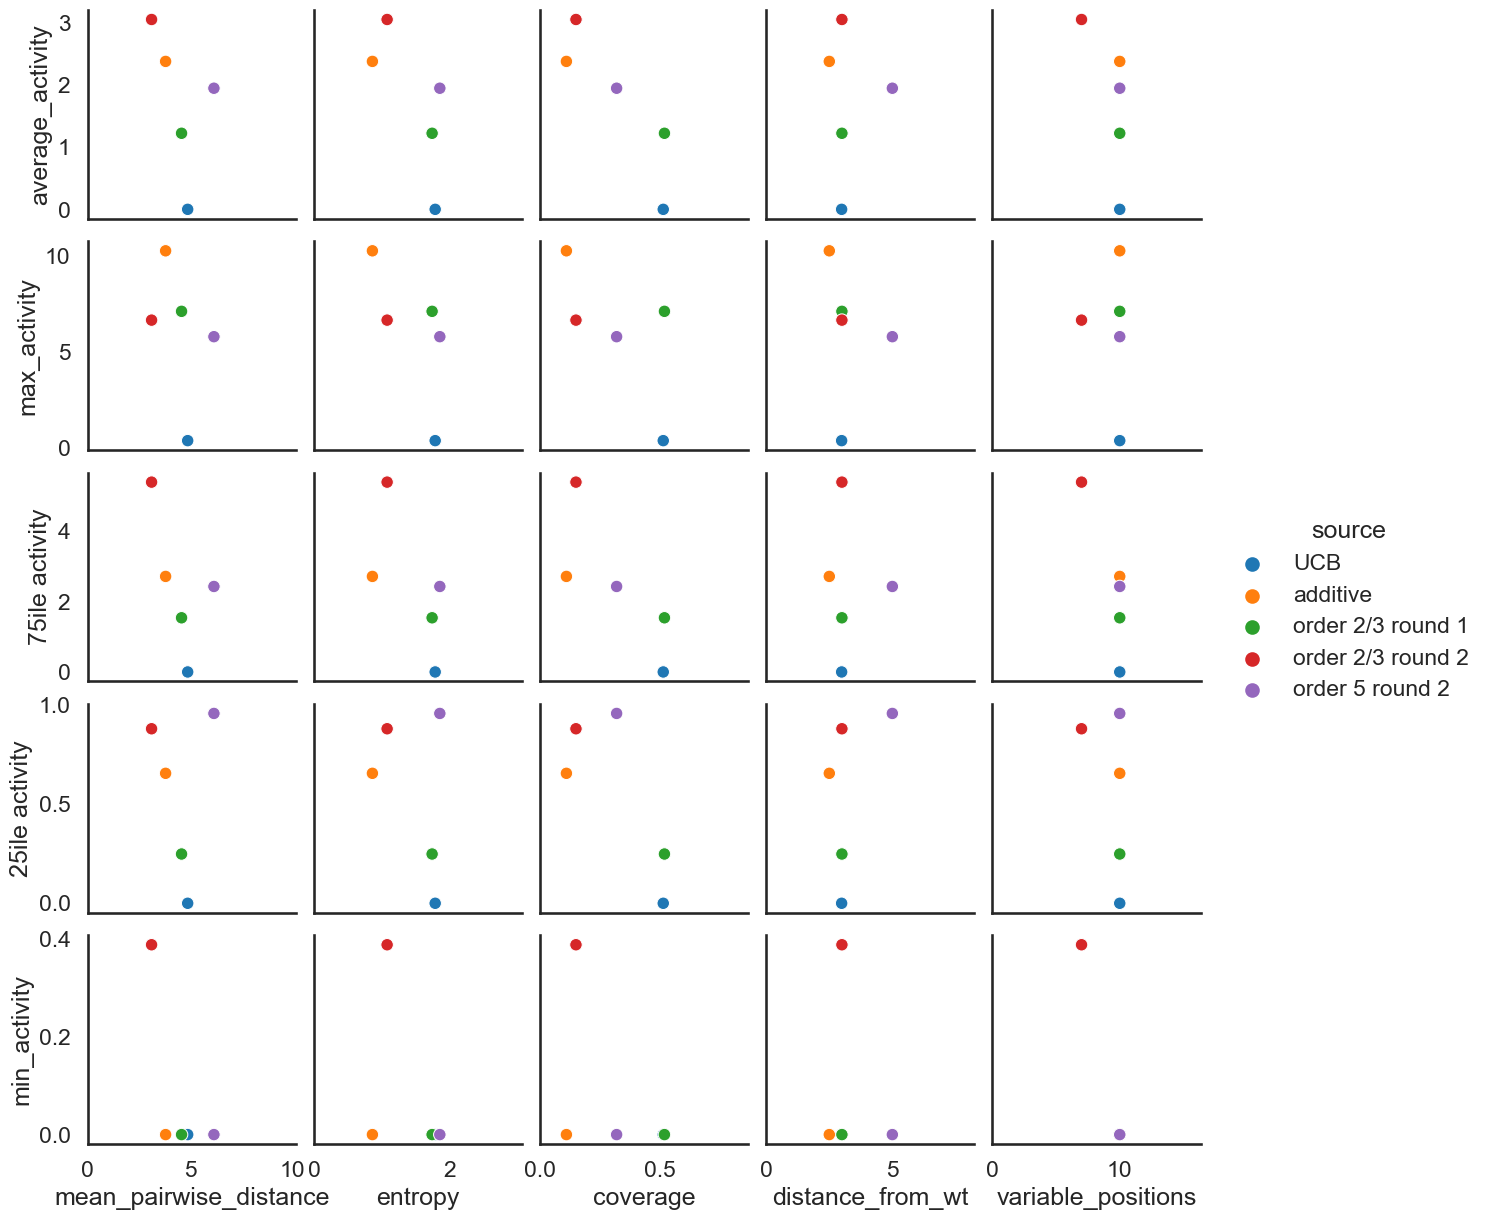

In [52]:
sns.pairplot(
    source_metrics[~source_metrics['source'].isin(['ssm', 'TA'])],
    hue='source',
    y_vars=['average_activity', 'max_activity', '75ile activity', '25ile activity', 'min_activity'],
    x_vars=['mean_pairwise_distance', 'entropy', 'coverage', 'distance_from_wt', 'variable_positions'],
)
# set all x axis lims to start at 0
for ax in plt.gcf().axes:
    ax.set_xlim(0, ax.get_xlim()[1]*1.1)

In [53]:
ax.get_lines()

<a list of 0 Line2D objects>

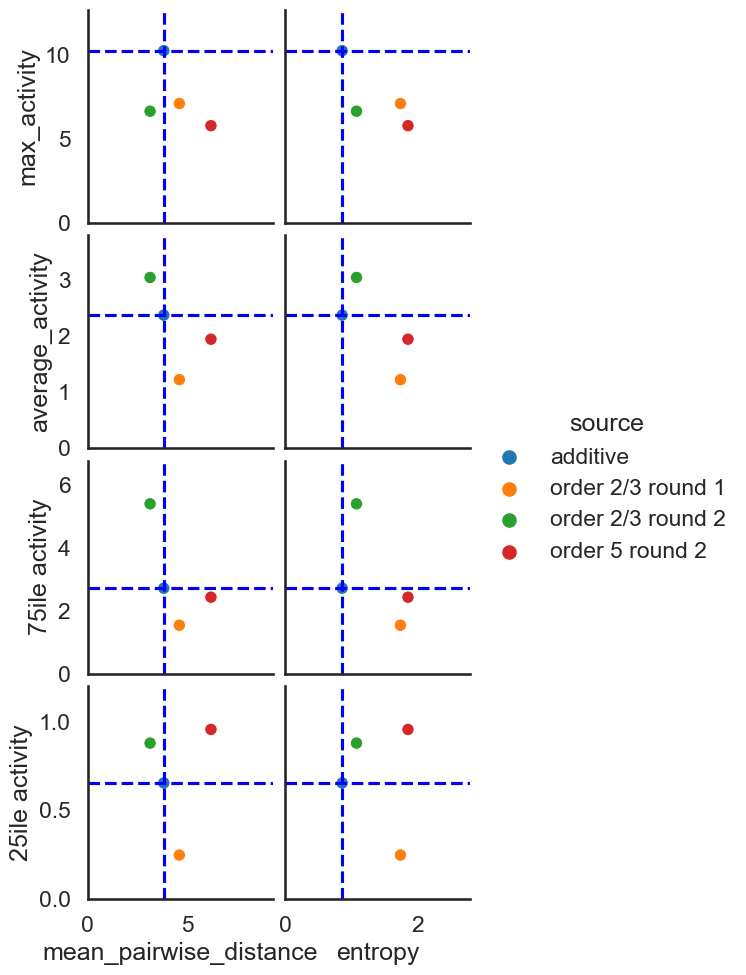

In [54]:
plot_df_ = source_metrics[~source_metrics['source'].isin(['ssm', 'TA', 'UCB'])]
sns.pairplot(
    plot_df_,
    hue='source',
    y_vars=['max_activity','average_activity', '75ile activity', '25ile activity'],
    x_vars=['mean_pairwise_distance', 'entropy'],
)
# set all x axis lims to start at 0
for ax in plt.gcf().axes:
    ax.set_xlim(0, ax.get_xlim()[1]*1.1)
    ax.set_ylim(0, ax.get_ylim()[1]*1.1)

    # also plot blue horizontal and vertical lines intersecting at source == 'additive'
    dp_index = np.where(plot_df_ == 'additive')[0][0]
    d = ax.collections[0].get_offsets()[dp_index]
    ax.axhline(y=d[1], color='blue', linestyle='--')
    ax.axvline(x=d[0], color='blue', linestyle='--')

## Selectivity of a small training set for substrate scope plate.

In [55]:
# dowselect to only variants with > 1.3 wild type activity
putative_variants = combined_data[combined_data['activity'] > 1.5].copy().reset_index(drop=True)

In [56]:
len(putative_variants)

151

#### First try clustering with pairwise distance based on blosum score

In [57]:
from sklearn.metrics import pairwise_distances

In [58]:
variant_strings = putative_variants['variant'].tolist()

In [59]:
variant_strings.append(wt)

In [60]:
# import blosum matrix
from Bio.Align import substitution_matrices
mat =  substitution_matrices.load("BLOSUM62")

In [61]:
variants = ap.ProteinSequences.from_list(variant_strings)

In [62]:
variant_array = variants.as_array()
variant_array = variant_array[:,variants.mutated_positions]

In [63]:
def get_score(arr1, arr2):
    """
    Calculate the BLOSUM62 score for two sequences.
    
    Parameters:
    -----------
    arr1 : numpy.ndarray
        array of strings, amino acids"
    arr2 : numpy.ndarray
        array of strings, amino acids"
    """
    score = 0
    for i in range(len(arr1)):
        score += mat[arr1[i], arr2[i]]
    return score

pairwise_scores = np.zeros((len(variant_array), len(variant_array)))
for i, j in itertools.combinations(range(len(variant_array)), 2):
    pairwise_scores[i, j] = get_score(variant_array[i], variant_array[j])
    pairwise_scores[j, i] = pairwise_scores[i, j]
# add diagonal
for i in range(len(variant_array)):
    pairwise_scores[i, i] = get_score(variant_array[i], variant_array[i])


In [64]:
pairwise_scores = pairwise_scores/np.max(pairwise_scores)

In [65]:
# convert to distance
pairwise_dist = np.exp(-pairwise_scores)

In [66]:
putative_variants_activities = putative_variants['activity'].to_list() + [1.0]
activity_distance_matrix = pairwise_distances(np.array(putative_variants_activities).reshape(-1,1), metric='euclidean')

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(20.20833333333333, 0.5, 'Activity distance')

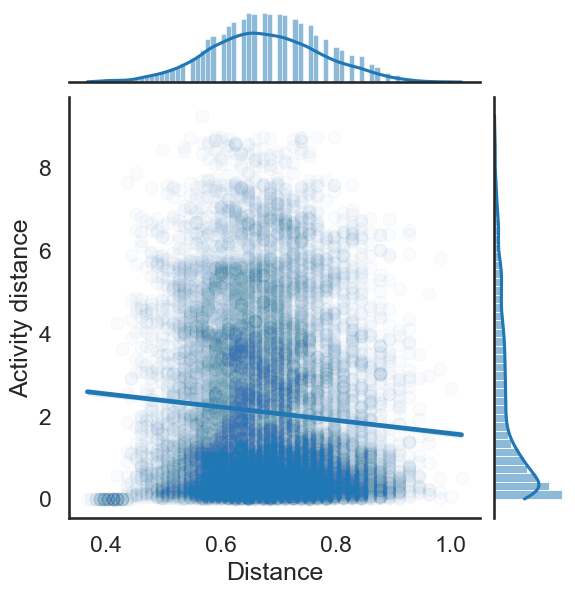

In [67]:
sns.jointplot(
    x=pairwise_dist.flatten(),
    y=activity_distance_matrix.flatten(),
    kind='reg',
    joint_kws={'scatter_kws': {'alpha': 0.01}},)

plt.xlabel('Distance')
plt.ylabel('Activity distance')

In [68]:
from umap import UMAP

In [69]:
mapper = UMAP(
    n_neighbors=5,
    min_dist=0.1,
    metric='precomputed',
    random_state=42,
    n_components=2
)
mapping = mapper.fit_transform(pairwise_dist)

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [70]:
sources = putative_variants['source'].to_list()
wt_index = -1
A399G_index = putative_variants[putative_variants['id'] == 'ssm_A399G'].index[0]
V83G_index = putative_variants[putative_variants['id'] == 'ssm_V83G'].index[0]

In [71]:
sources.append('WT')

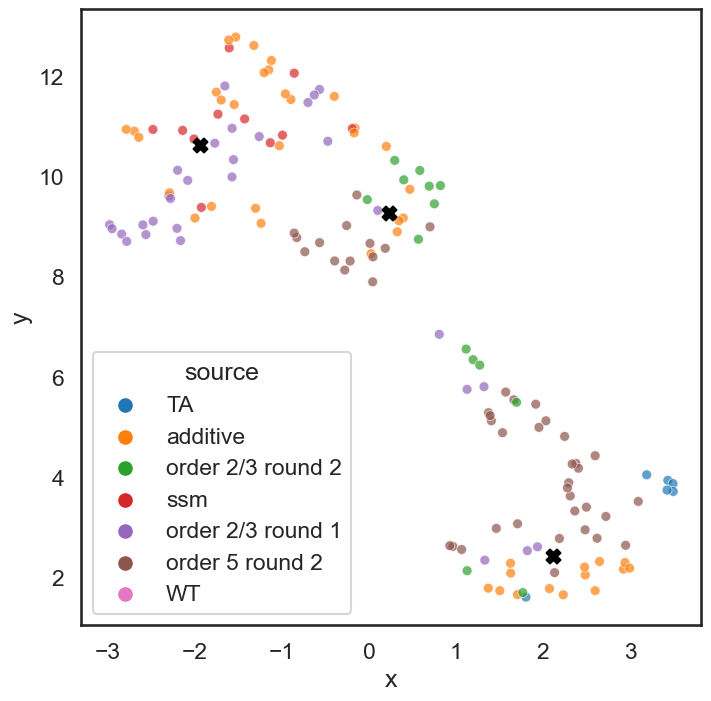

In [72]:
# plot the umap
plot_df = pd.DataFrame(mapping, columns=['x', 'y'])
plot_df['source'] = sources

fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(
    data=plot_df,
    x='x',
    y='y',
    hue='source',
    palette='tab10',
    ax=ax,
    s=50,
    alpha=0.7,
)
plt.scatter(mapping[wt_index, 0], mapping[wt_index, 1], c='black', s=100, label='WT', marker='X')
plt.scatter(mapping[A399G_index, 0], mapping[A399G_index, 1], c='black', s=100, label='A399G', marker='X')
plt.scatter(mapping[V83G_index, 0], mapping[V83G_index, 1], c='black', s=100, label='V83G', marker='X')


In [73]:
# iterative select variants based on maximum minimum distance
starting_indexes = [wt_index, A399G_index, V83G_index]
starting_selection_mask = np.zeros(len(variant_array), dtype=bool)
starting_selection_mask[starting_indexes] = True

In [74]:
while sum(starting_selection_mask) < 24:
    # get the pdistance of currently selected variants to all variants
    d_from_selected = pairwise_dist[starting_selection_mask, :]

    # get minimum distance to selected variants of all variants
    min_dist = np.min(d_from_selected, axis=0)

    # manually set distance of selected variants to 0
    min_dist[starting_selection_mask] = 0

    # get the index of the variant with the maximum minimum distance
    max_index = np.argmax(min_dist)
    # add to selected variants
    starting_selection_mask[max_index] = True


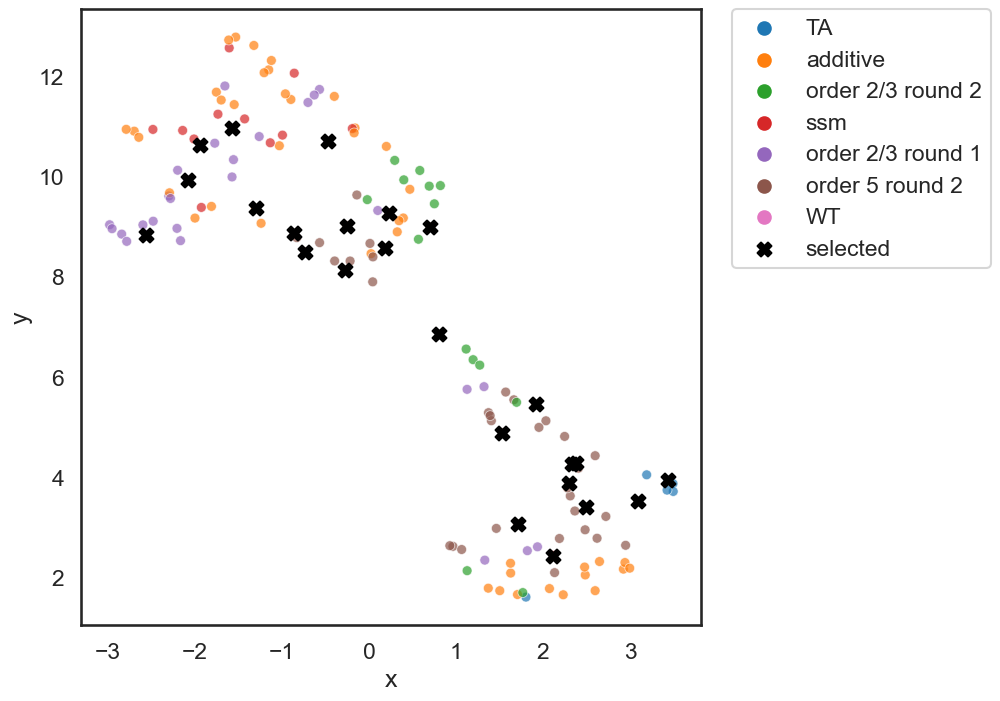

In [75]:
# replot
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(
    data=plot_df,
    x='x',
    y='y',
    hue='source',
    palette='tab10',
    ax=ax,
    s=50,
    alpha=0.7,
)
plt.scatter(mapping[starting_selection_mask, 0], mapping[starting_selection_mask, 1], c='black', s=100, label='selected', marker='X')
# move legend outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [76]:
# plot average activity of selected
selected = putative_variants[starting_selection_mask[:-1]]

In [77]:
selected['source'].value_counts()

source
order 5 round 2      14
order 2/3 round 1     5
ssm                   2
TA                    1
additive              1
Name: count, dtype: int64

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='activity', ylabel='Density'>

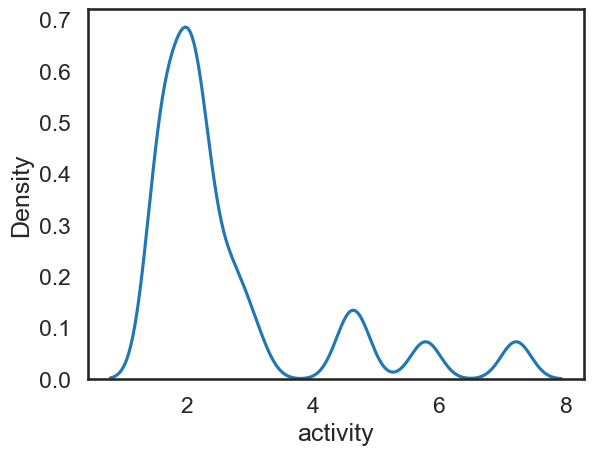

In [78]:
sns.kdeplot(
    data = selected,
    x='activity',
    fill=False,
    common_norm=True, 
    cumulative=False,
    bw_adjust=0.3,
)

### Try instead with a esm2 embeddings

In [79]:
all_variants = ap.ProteinSequences.from_list(combined_data['variant'].tolist())
all_variable_positions = all_variants.mutated_positions

In [80]:
esm_high_res = ap.ESM2Embedding(
    metadata_folder='.../embedders/esm2_individual',
    device='mps',
    model_checkpoint='esm2_t12_35M_UR50D',
    pool=None,
    flatten=True,
    positions=all_variable_positions
)
esm_high_res.fit([])
esm_embeddings = esm_high_res.transform(variants)

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [81]:
scaler = StandardScaler()
esm_embeddings_scaled = scaler.fit_transform(esm_embeddings)
esm_embeddings_dim_red = PCA(n_components=0.98).fit_transform(esm_embeddings_scaled)

In [82]:
from sklearn.metrics import pairwise_distances

In [83]:
distance_matrix = pairwise_distances(esm_embeddings_dim_red, metric='euclidean')

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


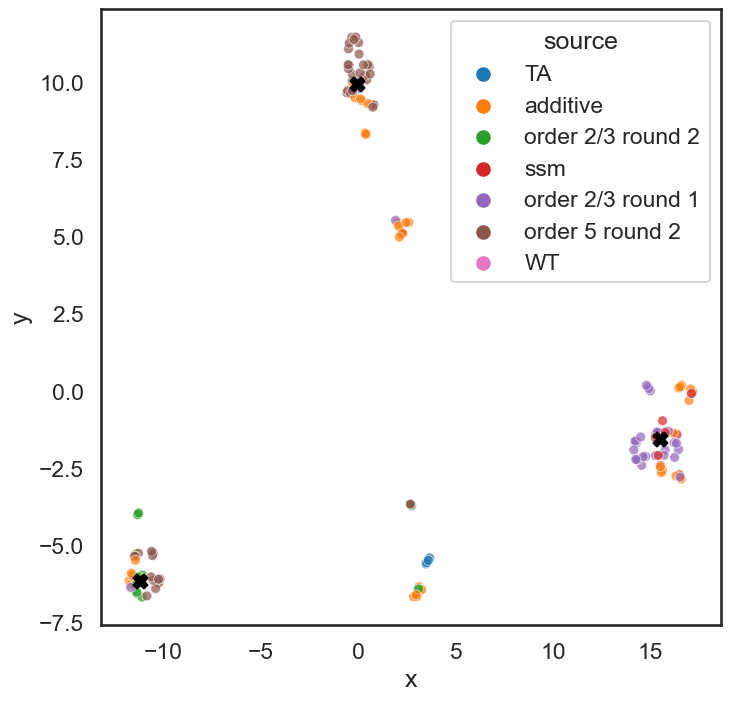

In [84]:
mapper = UMAP(
    n_neighbors=5,
    min_dist=0.1,
    metric='precomputed',
    random_state=42,
    n_components=2
)
mapping = mapper.fit_transform(distance_matrix)
# plot the umap
plot_df = pd.DataFrame(mapping, columns=['x', 'y'])
plot_df['source'] = sources
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(
    data=plot_df,
    x='x',
    y='y',
    hue='source',
    palette='tab10',
    ax=ax,
    s=50,
    alpha=0.7,
)
plt.scatter(mapping[wt_index, 0], mapping[wt_index, 1], c='black', s=100, label='WT', marker='X')
plt.scatter(mapping[A399G_index, 0], mapping[A399G_index, 1], c='black', s=100, label='A399G', marker='X')
plt.scatter(mapping[V83G_index, 0], mapping[V83G_index, 1], c='black', s=100, label='V83G', marker='X')


Plot distance in sequence space vs distance in activity space

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(20.20833333333333, 0.5, 'Activity distance')

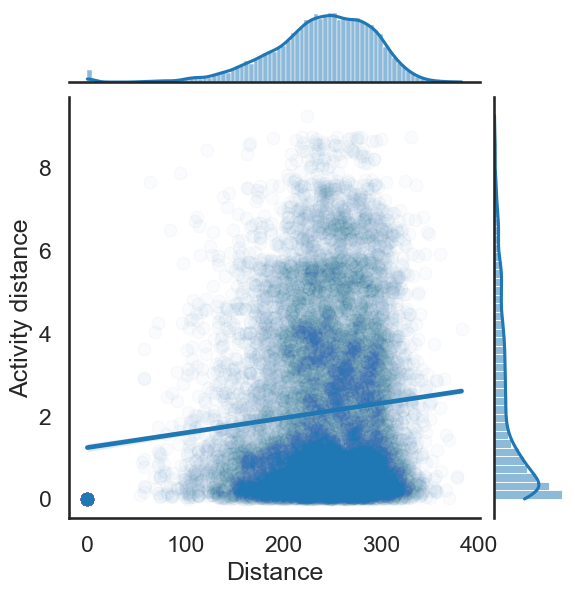

In [85]:
sns.jointplot(
    x=distance_matrix.flatten(),
    y=activity_distance_matrix.flatten(),
    kind='reg',
    joint_kws={'scatter_kws': {'alpha': 0.01}},)

plt.xlabel('Distance')
plt.ylabel('Activity distance')


In [86]:
# iterative select variants based on maximum minimum distance
starting_indexes = [wt_index, A399G_index, V83G_index]
starting_selection_mask = np.zeros(len(variant_array), dtype=bool)
starting_selection_mask[starting_indexes] = True

In [87]:
while sum(starting_selection_mask) < 24:
    # get the pdistance of currently selected variants to all variants
    d_from_selected = distance_matrix[starting_selection_mask, :]

    # get minimum distance to selected variants of all variants
    min_dist = np.min(d_from_selected, axis=0)

    # manually set distance of selected variants to 0
    min_dist[starting_selection_mask] = 0

    # get the index of the variant with the maximum minimum distance
    max_index = np.argmax(min_dist)
    # add to selected variants
    starting_selection_mask[max_index] = True


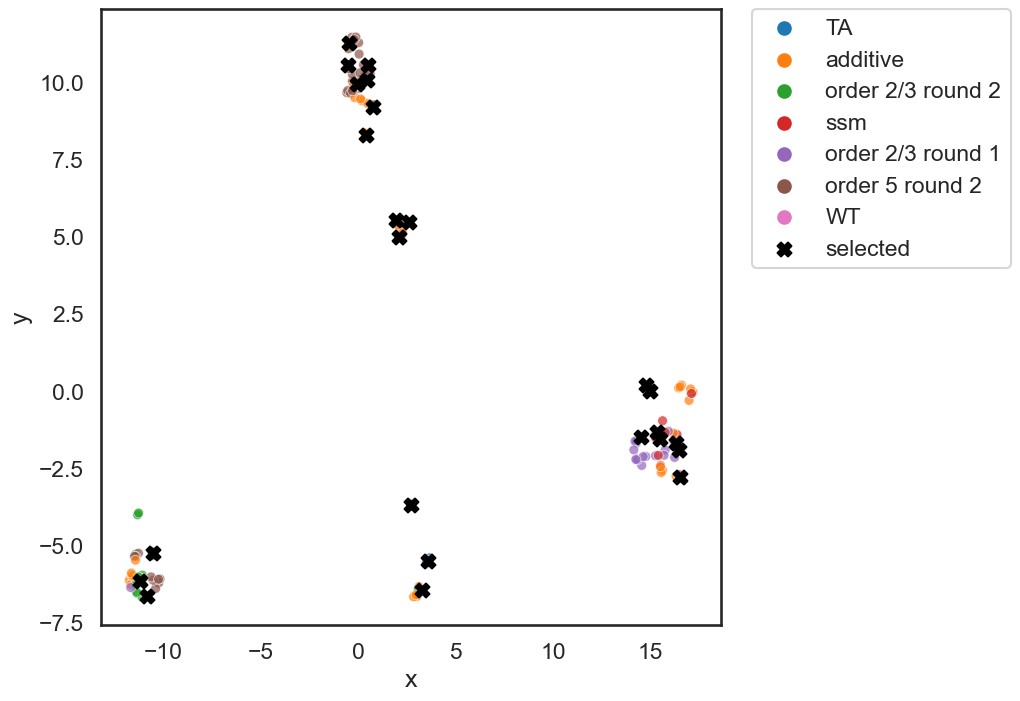

In [88]:
# replot
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(
    data=plot_df,
    x='x',
    y='y',
    hue='source',
    palette='tab10',
    ax=ax,
    s=50,
    alpha=0.7,
)
plt.scatter(mapping[starting_selection_mask, 0], mapping[starting_selection_mask, 1], c='black', s=100, label='selected', marker='X')
# move legend outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

In [89]:
# plot average activity of selected
selected = putative_variants[starting_selection_mask[:-1]]

In [90]:
selected['source'].value_counts()

source
order 2/3 round 1    8
order 5 round 2      8
additive             4
ssm                  2
TA                   1
Name: count, dtype: int64

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='activity', ylabel='Density'>

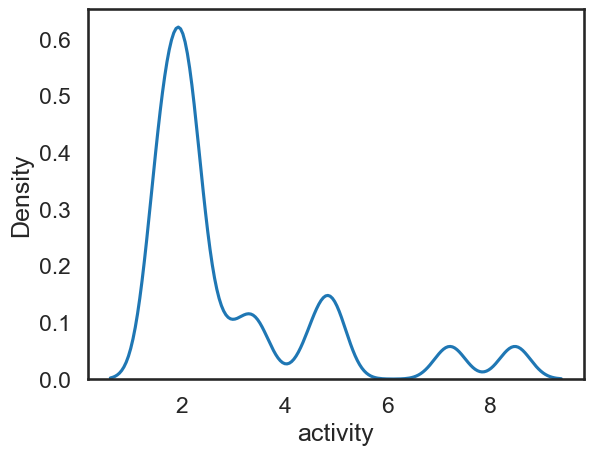

In [91]:
sns.kdeplot(
    data = selected,
    x='activity',
    fill=False,
    common_norm=True, 
    cumulative=False,
    bw_adjust=0.3,
)

### Let's constrain this significantly. Only single point mutations (including  A399 and V83, which have already been selected for).

Try to pick the most diverse set while retaining SOME activity: Do basically all of the embeddings types to get the most descriptive full sequence description that we can

In [92]:
ssm_data = combined_data[combined_data['source'] == 'ssm']

In [93]:
ssm_data['position'] = ssm_data['id'].apply(lambda x: int(x.split('_')[1][1:-1]))

/var/folders/4b/6yg7r65x0152cnhzpgzdhmvrjcvswz/T/ipykernel_64254/1403065074.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ssm_data['position'] = ssm_data['id'].apply(lambda x: int(x.split('_')[1][1:-1]))


In [94]:
positions = ssm_data.groupby('position')['activity'].max().sort_values(ascending=False).head(10).index

In [95]:
ssm_pool = ssm_data[ssm_data['position'].isin(positions)]

In [96]:
# also fold change filter
ssm_pool = ssm_pool[ssm_pool['activity'] > 0.8]

In [97]:
# add wt
ssm_pool = pd.concat([ssm_pool, pd.DataFrame({
    'id': ['WT'],
    'hash': [protein_hash(str(wt))],
    'variant': [str(wt)],
    'activity': [1.0]
})], axis=0).reset_index(drop=True)

In [98]:
ssm_pool

,hash,variant,activity,id,source,num_mutations,method,ohe,position
0,08c92251d61c194bf85c86d2fd28b141,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,1.842972,ssm_A399E,ssm,1.0,ssm,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",399.0
1,0be42036d32e6f37d95cb09b3167f256,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,0.912163,ssm_A570I,ssm,1.0,ssm,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",570.0
2,0f90402cba37ee103b3a197e32548fd3,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,0.820972,ssm_T561L,ssm,1.0,ssm,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",561.0
3,115f9891114f4798d87d5819271b676b,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,1.093565,ssm_A399S,ssm,1.0,ssm,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",399.0
4,1350a2e348fb4b83ec398de1cc4c6e67,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,1.288683,ssm_T561G,ssm,1.0,ssm,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",561.0
...,...,...,...,...,...,...,...,...,...
64,f94de5cb4860607215a486a4da80dc31,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,2.749185,ssm_V83G,ssm,1.0,ssm,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",83.0
65,f9e23acb8e41b3eb6eb4dd557977caf3,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,1.631296,ssm_A570K,ssm,1.0,ssm,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",570.0
66,fd2e069b8176b6ff07c19d4624b3b33f,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,1.046507,ssm_A570Y,ssm,1.0,ssm,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",570.0
67,fffedf0c1c7dd672f98b272b9feffa15,MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTG...,0.827324,ssm_G556W,ssm,1.0,ssm,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",556.0


Do a really extensize embedding....

In [99]:
esm_mean = ap.ESM2Embedding(
    metadata_folder='../embedders/esm2',
    device='mps',
    model_checkpoint='esm2_t36_3B_UR50D',
    pool='mean',
    flatten=False,
    use_cache=True,
    batch_size=4)
esm_mean.fit()

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t36_3B_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ESM2Embedding(batch_size=4, device='mps', metadata_folder='../embedders/esm2',
              model_checkpoint='esm2_t36_3B_UR50D', pool='mean',
              use_cache=True)

In [100]:
X_mean = esm_mean.transform(ssm_pool['variant'].tolist())

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t36_3B_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Computing ESM2 embeddings: 100%|██████████| 69/69 [00:41<00:00,  1.66it/s]


In [101]:
esm_max = ap.ESM2Embedding(
    metadata_folder='../embedders/esm2',
    device='mps',
    model_checkpoint='esm2_t36_3B_UR50D',
    pool='max',
    flatten=False,
    use_cache=True,
    batch_size=4)
esm_max.fit()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t36_3B_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ESM2Embedding(batch_size=4, device='mps', metadata_folder='../embedders/esm2',
              model_checkpoint='esm2_t36_3B_UR50D', pool='max', use_cache=True)

In [102]:
X_max = esm_max.transform(ssm_pool['variant'].tolist())

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t36_3B_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Computing ESM2 embeddings: 100%|██████████| 69/69 [00:40<00:00,  1.69it/s]


In [103]:
esm_min = ap.ESM2Embedding(
    metadata_folder='../embedders/esm2',
    device='mps',
    model_checkpoint='esm2_t36_3B_UR50D',
    pool='min',
    flatten=False,
    use_cache=True,
    batch_size=4)
esm_min.fit()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t36_3B_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ESM2Embedding(batch_size=4, device='mps', metadata_folder='../embedders/esm2',
              model_checkpoint='esm2_t36_3B_UR50D', pool='min', use_cache=True)

In [104]:
X_min = esm_min.transform(ssm_pool['variant'].tolist())

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t36_3B_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Computing ESM2 embeddings: 100%|██████████| 69/69 [00:41<00:00,  1.67it/s]


In [106]:
esm_flatten = ap.ESM2Embedding(
    metadata_folder='../embedders/esm2',
    device='mps',
    model_checkpoint='esm2_t36_3B_UR50D',
    pool=None,
    flatten=True,
    use_cache=True,
    batch_size=4)

esm_flatten.fit()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t36_3B_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ESM2Embedding(batch_size=4, device='mps', flatten=True,
              metadata_folder='../embedders/esm2',
              model_checkpoint='esm2_t36_3B_UR50D', use_cache=True)

In [107]:
X_flatten = esm_flatten.transform(ssm_pool['variant'].tolist())

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t36_3B_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Computing ESM2 embeddings: 100%|██████████| 69/69 [00:40<00:00,  1.69it/s]


In [108]:
esm_median = ap.ESM2Embedding(
    metadata_folder='../embedders/esm2',
    device='mps',
    model_checkpoint='esm2_t36_3B_UR50D',
    pool='median',
    flatten=False,
    use_cache=True,
    batch_size=4)
esm_median.fit()

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t36_3B_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


ESM2Embedding(batch_size=4, device='mps', metadata_folder='../embedders/esm2',
              model_checkpoint='esm2_t36_3B_UR50D', pool='median',
              use_cache=True)

In [109]:
X_median = esm_median.transform(ssm_pool['variant'].tolist())

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t36_3B_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Computing ESM2 embeddings: 100%|██████████| 69/69 [00:42<00:00,  1.61it/s]


In [110]:
X = np.concatenate([X_mean, X_max, X_min, X_flatten, X_median], axis=1)

In [111]:
X = StandardScaler().fit_transform(X)

In [112]:
X.shape

(69, 1456640)

#### Compute PCA of all features, select most diverse set starting from A399 and V83, WT

In [334]:
X_pca = PCA(n_components=0.999).fit_transform(X)
X_pca.shape

(69, 64)

Text(0.5, 0, 'Principal Component')

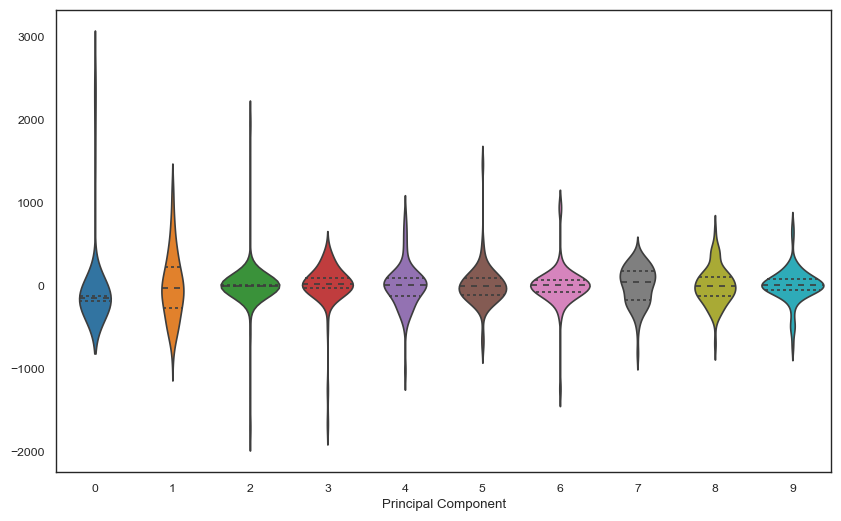

In [335]:
# make a violing plot of first 10 PCs
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=X_pca[:, :10],
    ax=ax,
    inner='quartile',
    palette='tab10'
)
plt.xlabel('Principal Component')

Text(0.5, 0, 'Principal Component')

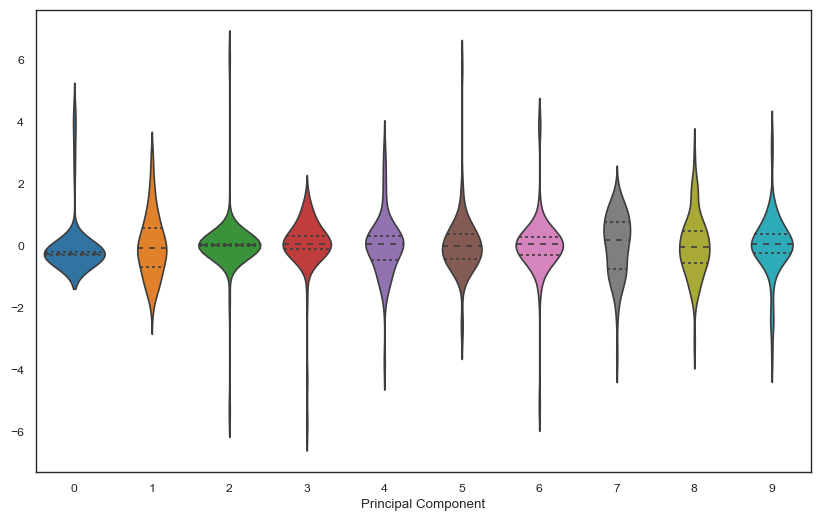

In [336]:
X_pca_st = StandardScaler().fit_transform(X_pca)
# make a violing plot of first 10 PCs
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=X_pca_st[:, :10],
    ax=ax,
    inner='quartile',
    palette='tab10'
)
plt.xlabel('Principal Component')
#X_pca = X_pca_st

In [337]:
pairwise_dist = pairwise_distances(X_pca, metric='euclidean')

In [338]:
pairwise_dist

array([[   0.    , 2402.0493, 2321.3025, ..., 2659.344 , 2301.4612,
        2088.3242],
       [2402.0493,    0.    , 1143.6621, ...,  937.3609, 1483.2665,
        1081.8138],
       [2321.3025, 1143.6621,    0.    , ..., 1629.9357, 1335.0819,
         924.3392],
       ...,
       [2659.344 ,  937.3609, 1629.9357, ...,    0.    , 1842.4149,
        1600.1276],
       [2301.4612, 1483.2665, 1335.0819, ..., 1842.4149,    0.    ,
        1033.6093],
       [2088.3242, 1081.8138,  924.3392, ..., 1600.1276, 1033.6093,
           0.    ]], dtype=float32)

In [339]:
starting_indexes = ssm_pool[ssm_pool['id'].isin(['WT', 'ssm_A399G', 'ssm_V83G'])].index.tolist()

In [340]:
starting_indexes

[36, 64, 68]

In [341]:
indexes_selected = starting_indexes.copy()
while len(indexes_selected) < 20:
    # get the pdistance of currently selected variants to all variants
    # shape (n_selected, n_variants)
    d_from_selected = pairwise_dist[indexes_selected, :]

    # get minimum distance to selected variants of all variants
    # shape (n_variants,)
    min_dist = np.min(d_from_selected, axis=0)

    # manually set distance of selected variants to 0
    min_dist[indexes_selected] = 0

    # get the index of the variant with the maximum minimum distance
    max_index = np.argmax(min_dist)
    # add to selected variants
    indexes_selected.append(max_index)

In [342]:
indexes_selected

[36, 64, 68, 48, 38, 7, 0, 25, 59, 8, 66, 20, 30, 56, 52, 37, 60, 43, 9, 61]

In [343]:
from matplotlib.colors import Normalize, TwoSlopeNorm, LogNorm
from matplotlib.colorbar import ColorbarBase
from matplotlib.cm import ScalarMappable
sns.set_context('paper')

class CustomNorm(Normalize):
    def __init__(self, vmin, vcenter, vmax):
        super().__init__(vmin, vmax)
        self.vcenter = vcenter
        self.lower_norm = Normalize(vmin=vmin, vmax=vcenter)
        self.upper_norm = LogNorm(vmin=vcenter, vmax=vmax)

    def __call__(self, value, clip=None):
        lower = value <= self.vcenter
        upper = value > self.vcenter
        result = np.zeros_like(value, dtype=float)
        result[lower] = self.lower_norm(value[lower])/2.0
        result[upper] = 0.5 + 0.5 * self.upper_norm(value[upper])
        return result
    
    def inverse(self, value):
        lower = value <= 0.5
        upper = value > 0.5
        result = np.zeros_like(value, dtype=float)
        result[lower] = self.lower_norm.inverse(value[lower] * 2.0)
        result[upper] = self.upper_norm.inverse((value[upper] - 0.5) * 2.0)
        return result

def plot_mutation_heatmap(mutations, scores, all_positions=True, wt_activity=None, zero_minimum=False, log_scale_upper=False):
    """
    Plot a heatmap of single point mutation scores.
    
    Parameters:
    mutations (list): List of mutation strings (e.g., ["L1V", "A2G", ...])
    scores (list): List of corresponding scores
    all_positions (bool): If True, show all positions, even those without mutations
    wt_activity (float): Wild-type activity score for centering the colormap
    zero_minimum (bool): If True, set the minimum of the colormap to 0.0
    log_scale_upper (bool): If True, use log scale for upper half of colormap
    
    Returns:
    fig, ax: The created figure and axis objects
    """
    # All possible amino acids
    all_aas = 'ACDEFGHIKLMNPQRSTVWY'
    
    # Extract residue positions and mutant amino acids
    positions = [int(m[1:-1]) for m in mutations]
    mutant_aas = [m[-1] for m in mutations]
    original_aas = [m[0] for m in mutations]
    
    # Create a DataFrame
    df = pd.DataFrame({
        'Position': positions,
        'Mutant_AA': mutant_aas,
        'Original_AA': original_aas,
        'Score': scores
    })
    original_aa_dict = dict(zip(df['Position'], df['Original_AA']))
    
    if all_positions:
        # Create a full matrix with all amino acids and positions
        full_matrix = pd.DataFrame(index=range(1, max(positions)+1), columns=list(all_aas))
    else:
        full_matrix = pd.DataFrame(index=np.sort(np.unique(positions)), columns=list(all_aas))
    
    # Fill the matrix with scores
    for _, row in df.iterrows():
        full_matrix.at[row['Position'], row['Mutant_AA']] = row['Score']
    
    # Create the heatmap
    width = 8  # Increased width to accommodate colorbar
    height = 6/20 * len(full_matrix)
    fig, (ax, cax) = plt.subplots(1, 2, figsize=(width, height), 
                                  gridspec_kw={'width_ratios': [20, 1]})
    
    # Determine colormap and normalization
    if wt_activity is None:
        cmap = sns.color_palette("viridis", as_cmap=True)
        vmin = 0.0 if zero_minimum else np.nanmin(full_matrix.values)
        vmax = np.nanmax(full_matrix.values)
        norm = Normalize(vmin=vmin, vmax=vmax)
    else:
        cmap = sns.color_palette("vlag", as_cmap=True)
        vmin = 0.0 if zero_minimum else min(np.nanmin(full_matrix.values), wt_activity)
        vmax = max(np.nanmax(full_matrix.values), wt_activity)
        if log_scale_upper:
            norm = CustomNorm(vmin=vmin, vcenter=wt_activity, vmax=vmax)
        else:
            norm = TwoSlopeNorm(vmin=vmin, vcenter=wt_activity, vmax=vmax)
    
    # Plot the heatmap
    sns.heatmap(full_matrix.astype(np.float64), ax=ax, cmap=cmap, norm=norm,
                cbar=False, square=True, linewidths=0.5, linecolor='black',
                mask=full_matrix.isnull())
    
    # Create custom colorbar
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, cax=cax, label='Score')

    # Customize the plot
    ax.set_title('Single Point Mutation Scores')
    ax.set_xlabel('Mutant Amino Acid')
    ax.set_ylabel('Residue Position')
    
    # Add original amino acids to y-axis labels
    ax.set_yticks(np.array(range(len(full_matrix)))+0.5)
    ax.set_yticklabels([f'{original_aa_dict.get(i, "?")} {i}' for i in full_matrix.index])
    
    # Adjust aspect ratio to make cells square
    ax.set_aspect('equal')
    
    plt.tight_layout()
    
    return fig, ax, full_matrix

In [344]:
ssm_data_ = ssm_data[ssm_data['num_mutations'] == 1]    

In [345]:
strings = ssm_data_['variant'].apply(lambda x: get_mutations(wt, x, one_indexed=True)[0]).values

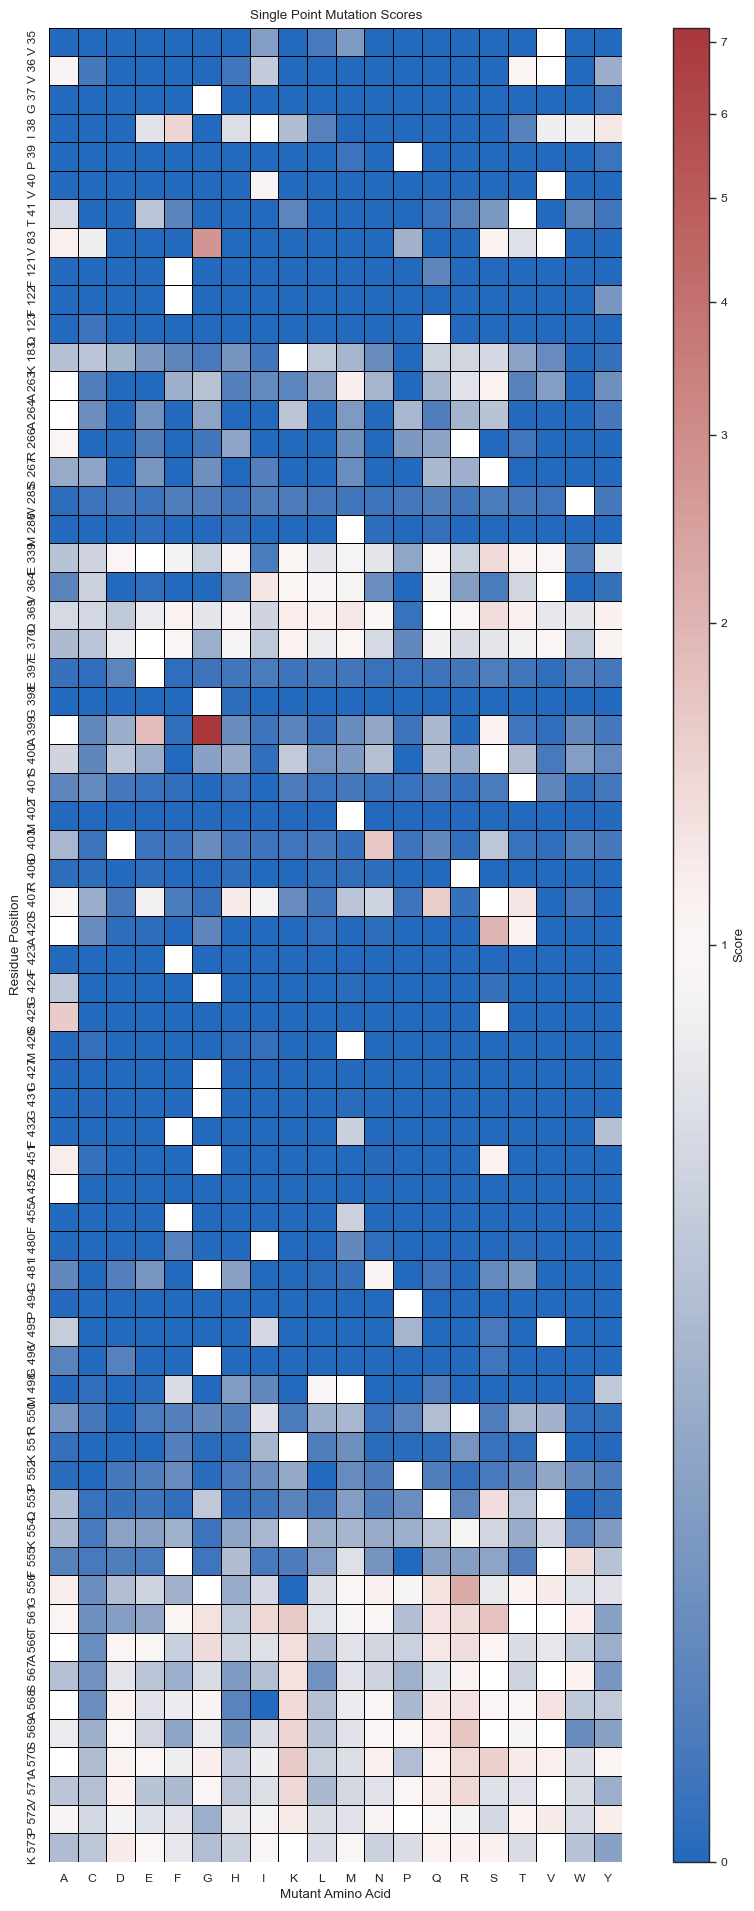

In [346]:
fig, ax, matrix = plot_mutation_heatmap(mutations = strings, scores = ssm_data_['activity'].values, all_positions=False, wt_activity=1.0, zero_minimum=True, log_scale_upper=True)

In [347]:
selected_ssm_df = ssm_pool.loc[indexes_selected].dropna()

In [348]:
# highlight chosen boxed
for _, row in selected_ssm_df.iterrows():
    mut_string = get_mutations(wt, row['variant'], one_indexed=True)[0]
    pos, to_aa = mut_string[1:-1], mut_string[-1]
    row_pos = matrix.index.get_loc(int(pos))
    col_pos = matrix.columns.get_loc(to_aa)
    ax.add_patch(plt.Rectangle((col_pos, row_pos), 1, 1, fill=False, edgecolor='red', lw=2))

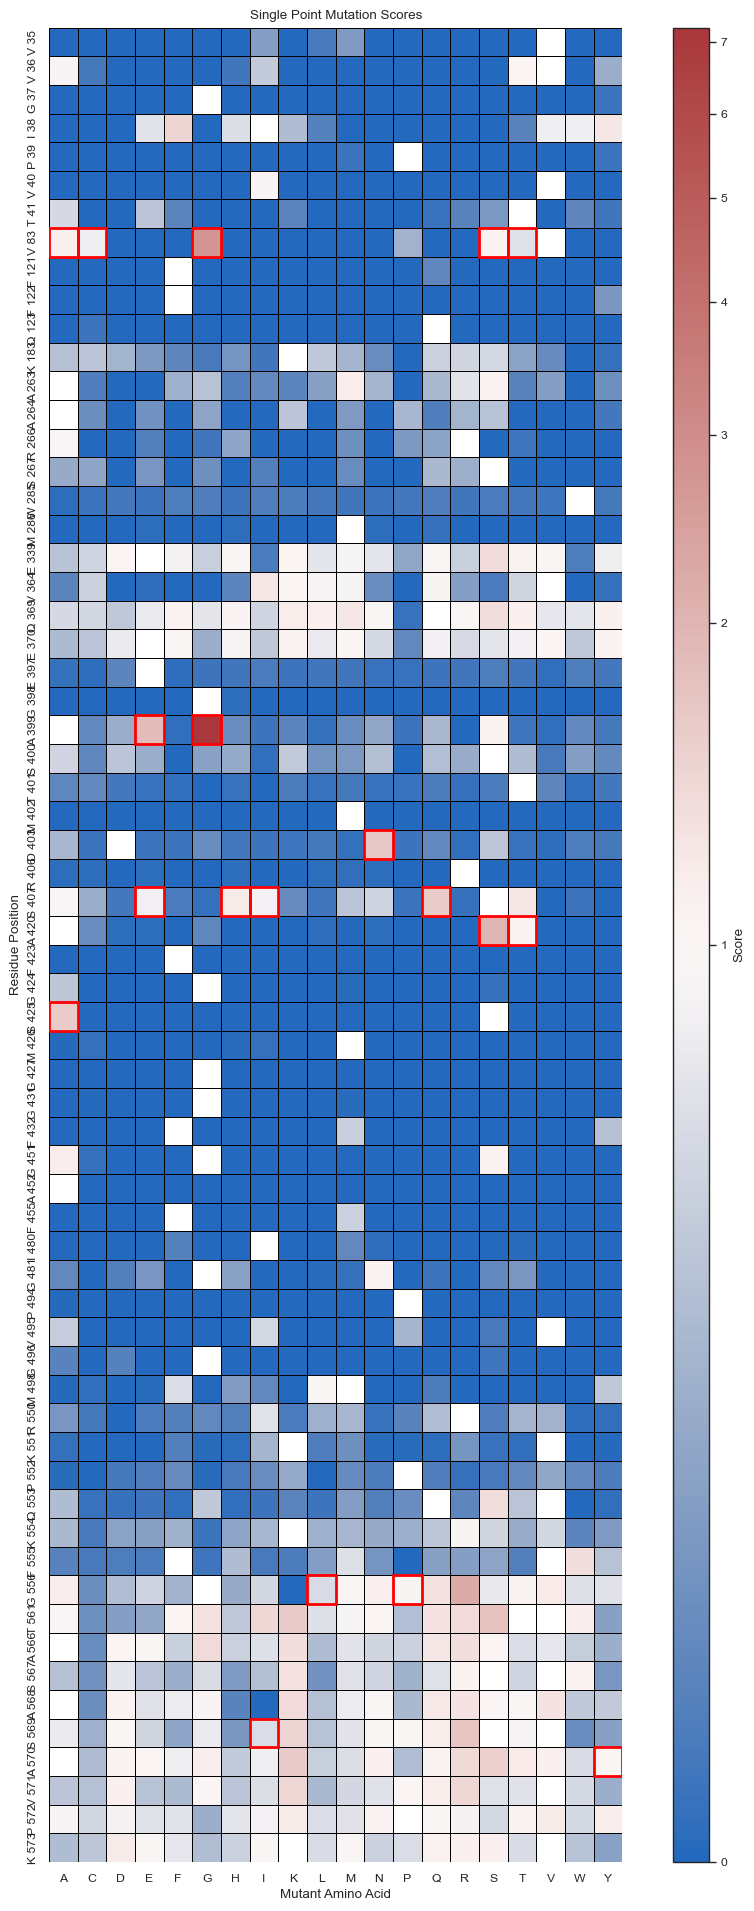

In [349]:
fig

Plot distribution of pairwise distances vs just those selected

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Density'>

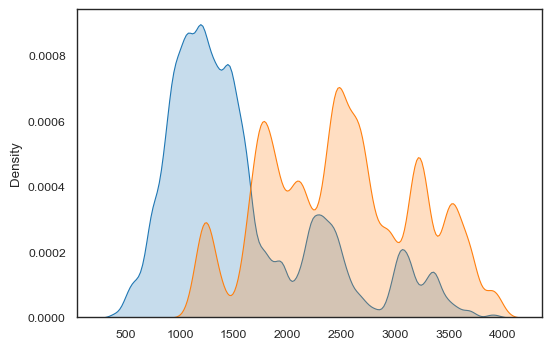

In [350]:
ind = np.tril_indices(len(pairwise_dist), -1)
all_distances = pairwise_dist[ind]
selected_distances = pairwise_dist[indexes_selected, :][:, indexes_selected]
ind = np.tril_indices(len(selected_distances), -1)
selected_distances = selected_distances[ind]
fig, ax = plt.subplots(figsize=(6, 4))
sns.kdeplot(
    all_distances,
    label='All distances',
    fill=True,
    common_norm=True, 
    cumulative=False,
    bw_adjust=0.3,
)
sns.kdeplot(
    selected_distances,
    label='Selected distances',
    fill=True,
    common_norm=True, 
    cumulative=False,
    bw_adjust=0.3,
)

Plot a umap of the PCA embedding and the selected points

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/4b/6yg7r65x0152cnhzpgzdhmvrjcvswz/T/ipykernel_64254/767591613.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


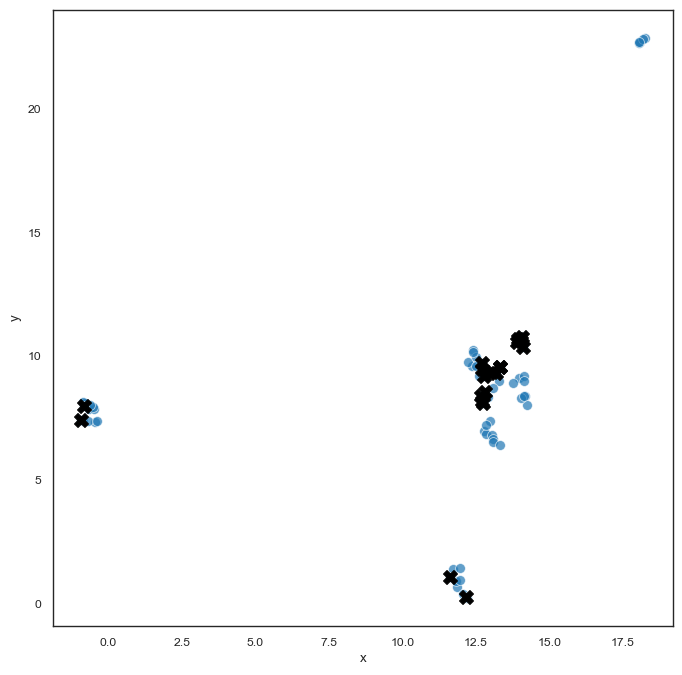

In [351]:
umap = UMAP(
    n_neighbors=5,
    min_dist=0.001,
    metric='precomputed',
    random_state=42,
    n_components=2
)
mapping = umap.fit_transform(pairwise_dist)
# plot the umap
plot_df = pd.DataFrame(mapping, columns=['x', 'y'])
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(
    data=plot_df,
    x='x',
    y='y',
    palette='tab10',
    ax=ax,
    s=50,
    alpha=0.7,
)
# now with xes the selected
plt.scatter(mapping[indexes_selected, 0], mapping[indexes_selected, 1], c='black', s=100, label='selected', marker='X')


#### Try ICA instead?

In [352]:
from sklearn.decomposition import FastICA
X_pca = PCA(n_components=0.999).fit_transform(X)
X_ica = FastICA(random_state=42).fit_transform(X_pca)

<Axes: >

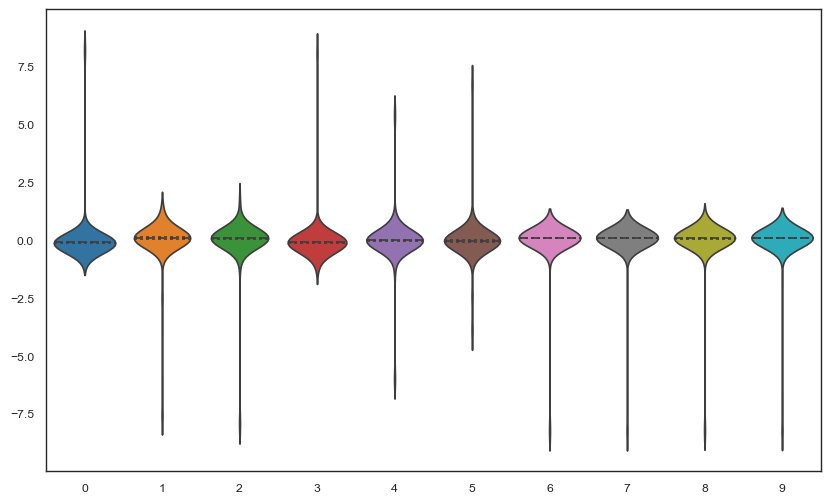

In [353]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=X_ica[:, :10],
    ax=ax,
    inner='quartile',
    palette='tab10'
)

In [354]:
X_ica = X_ica[:, :10]

In [355]:
pairwise_dist = pairwise_distances(X_ica, metric='euclidean')

In [356]:
starting_indexes = ssm_pool[ssm_pool['id'].isin(['WT', 'ssm_A399G', 'ssm_V83G'])].index.tolist()

In [357]:
starting_indexes

[36, 64, 68]

In [358]:
indexes_selected = starting_indexes.copy()
while len(indexes_selected) < 20:
    # get the pdistance of currently selected variants to all variants
    # shape (n_selected, n_variants)
    d_from_selected = pairwise_dist[indexes_selected, :]

    # get minimum distance to selected variants of all variants
    # shape (n_variants,)
    min_dist = np.min(d_from_selected, axis=0)

    # manually set distance of selected variants to 0
    min_dist[indexes_selected] = 0

    # get the index of the variant with the maximum minimum distance
    max_index = np.argmax(min_dist)
    # add to selected variants
    indexes_selected.append(max_index)

In [359]:
indexes_selected

[36, 64, 68, 9, 46, 4, 32, 6, 49, 29, 58, 57, 20, 51, 1, 21, 27, 45, 41, 23]

In [360]:
ssm_data_ = ssm_data[ssm_data['num_mutations'] == 1]    

In [361]:
strings = ssm_data_['variant'].apply(lambda x: get_mutations(wt, x, one_indexed=True)[0]).values

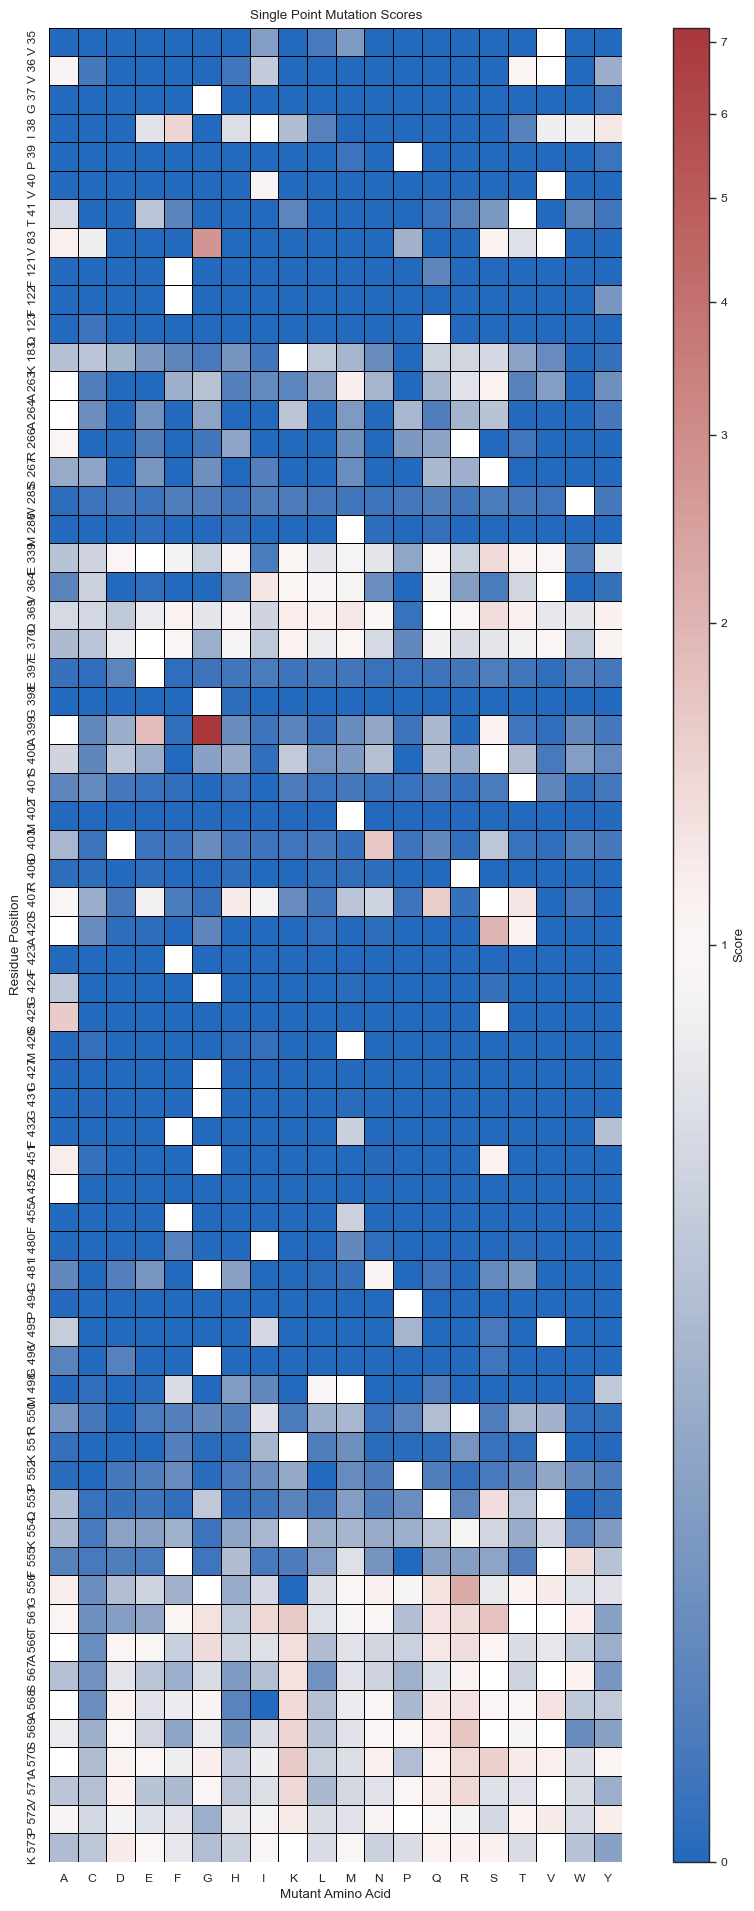

In [362]:
fig, ax, matrix = plot_mutation_heatmap(mutations = strings, scores = ssm_data_['activity'].values, all_positions=False, wt_activity=1.0, zero_minimum=True, log_scale_upper=True)

In [363]:
selected_ssm_df = ssm_pool.loc[indexes_selected].dropna()

In [364]:
# highlight chosen boxed
for _, row in selected_ssm_df.iterrows():
    mut_string = get_mutations(wt, row['variant'], one_indexed=True)[0]
    pos, to_aa = mut_string[1:-1], mut_string[-1]
    row_pos = matrix.index.get_loc(int(pos))
    col_pos = matrix.columns.get_loc(to_aa)
    ax.add_patch(plt.Rectangle((col_pos, row_pos), 1, 1, fill=False, edgecolor='red', lw=2))

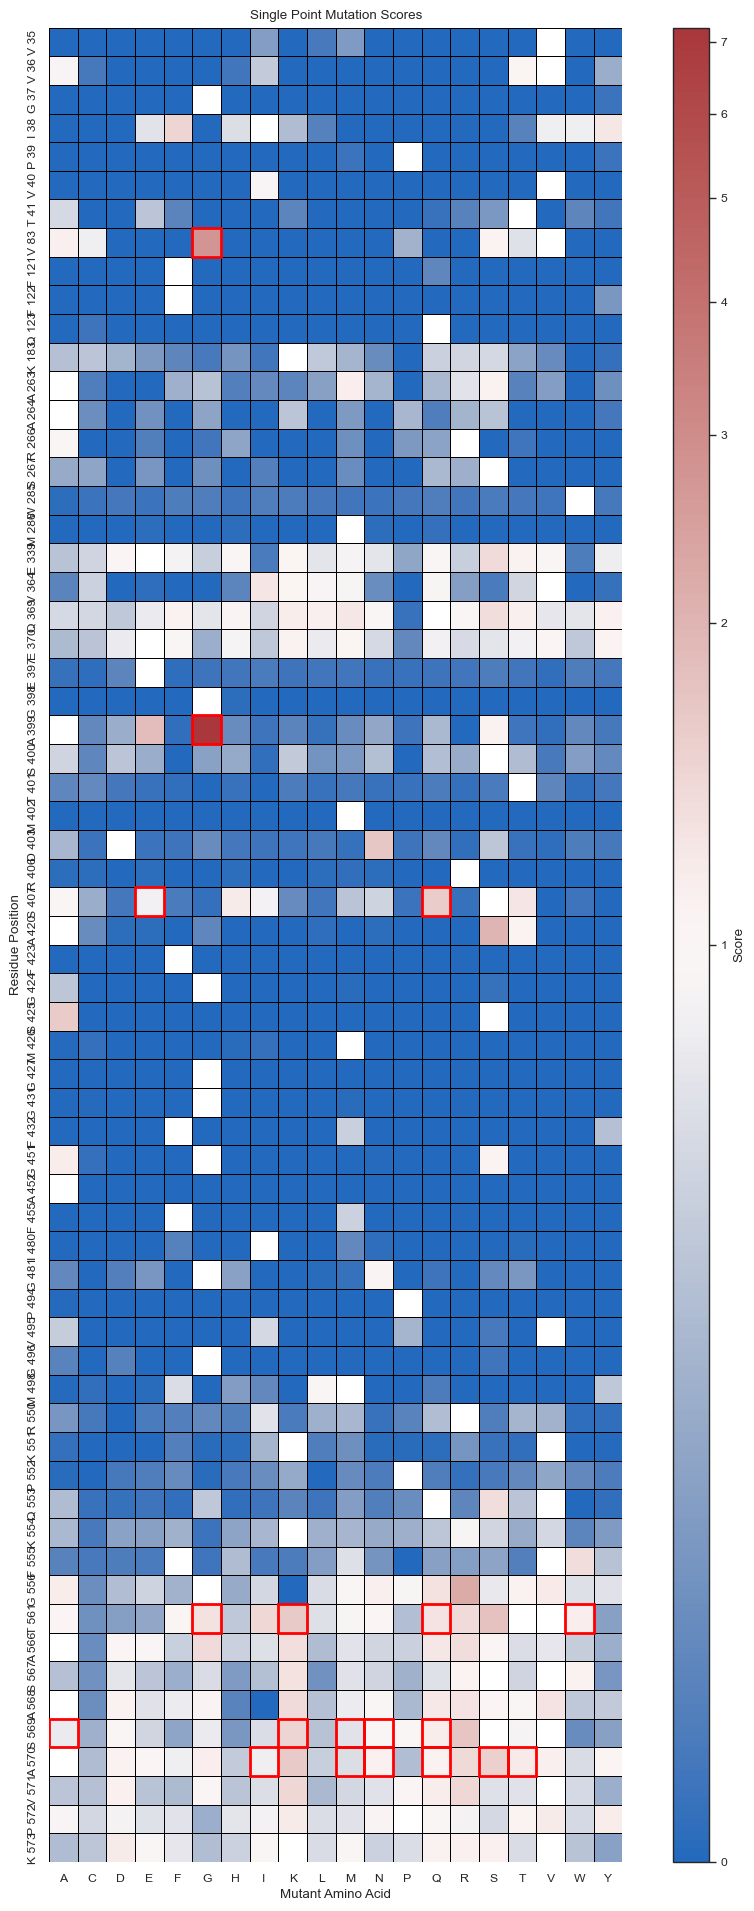

In [365]:
fig

Plot distribution of pairwise distances vs just those selected

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Density'>

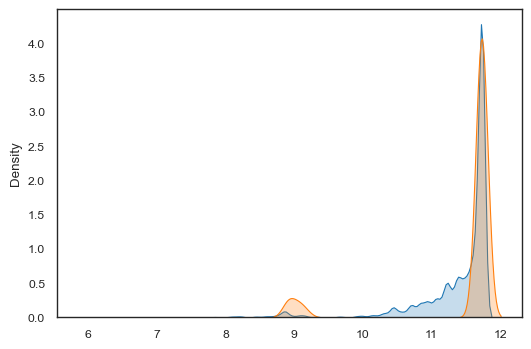

In [ ]:
ind = np.tril_indices(len(pairwise_dist), -1)
all_distances = pairwise_dist[ind]
selected_distances = pairwise_dist[indexes_selected, :][:, indexes_selected]
ind = np.tril_indices(len(selected_distances), -1)
selected_distances = selected_distances[ind]
fig, ax = plt.subplots(figsize=(6, 4))
sns.kdeplot(
    all_distances,
    label='All distances',
    fill=True,
    common_norm=True, 
    cumulative=False,
    bw_adjust=0.3,
)
sns.kdeplot(
    selected_distances,
    label='Selected distances',
    fill=True,
    common_norm=True, 
    cumulative=False,
    bw_adjust=0.3,
)

Plot a umap of the PCA embedding and the selected points

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/4b/6yg7r65x0152cnhzpgzdhmvrjcvswz/T/ipykernel_64254/767591613.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


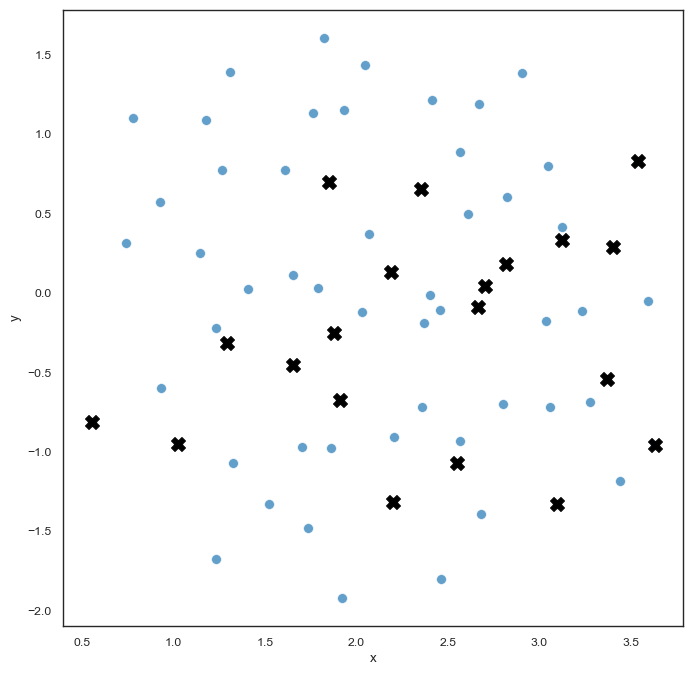

In [ ]:
umap = UMAP(
    n_neighbors=5,
    min_dist=0.001,
    metric='precomputed',
    random_state=42,
    n_components=2
)
mapping = umap.fit_transform(pairwise_dist)
# plot the umap
plot_df = pd.DataFrame(mapping, columns=['x', 'y'])
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(
    data=plot_df,
    x='x',
    y='y',
    palette='tab10',
    ax=ax,
    s=50,
    alpha=0.7,
)
# now with xes the selected
plt.scatter(mapping[indexes_selected, 0], mapping[indexes_selected, 1], c='black', s=100, label='selected', marker='X')
